Import bibliotek

In [ ]:
# Import bibliotek
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:,.2f}'.format)

Załadowanie danych

In [ ]:
# Załadowanie danych
df = pd.read_csv("sales_random.csv")

In [ ]:
df.head()

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
0,245750,146517_8.0502.245_BUD.127_LOK,"752,024.00","15,788.87",6,2,mieszkalna,PLN,47.63,2025-04-16,Ulica Instalatorów 7A,Warszawa
1,245746,146517_8.0502.245_BUD.68_LOK,"545,000.00","14,379.95",2,2,mieszkalna,PLN,37.90,2025-04-16,Ulica Instalatorów 7A,Warszawa
2,245751,146517_8.0502.245_BUD.94_LOK,"657,359.50","17,163.43",7,2,mieszkalna,PLN,38.30,2025-04-16,Ulica Instalatorów 7A,Warszawa
3,242913,146517_8.0826.117_BUD.58_LOK,"855,942.85","14,306.25",3,3,mieszkalna,PLN,59.83,2025-04-16,Aleje Jerozolimskie 190,Warszawa
4,241286,146514_8.1145.111_BUD.82_LOK,"598,424.89","11,521.46",3,3,mieszkalna,PLN,51.94,2025-04-16,Ulica Mieczysława Pożaryskiego 35A,Warszawa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_rcn_id    2500 non-null   int64  
 1   name           2500 non-null   object 
 2   amount         2500 non-null   float64
 3   amount_sqm     2500 non-null   float64
 4   floor_number   2500 non-null   int64  
 5   rooms_number   2500 non-null   int64  
 6   type           2500 non-null   object 
 7   currency       2500 non-null   object 
 8   size           2500 non-null   float64
 9   creation_date  2500 non-null   object 
 10  invest_name    2500 non-null   object 
 11  invest_city    2500 non-null   object 
dtypes: float64(3), int64(3), object(6)
memory usage: 234.5+ KB


In [ ]:
df['type'].value_counts()

type
mieszkalna    2500
Name: count, dtype: int64

In [ ]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size
count,"2,500.00","2,500.00","2,500.00","2,500.00","2,500.00","2,500.00"
mean,"156,672.83","1,881,912.15","28,384.37",3.94,2.74,57.59
std,"55,702.61","11,836,597.84","168,256.96",2.59,1.20,25.68
min,"52,087.00","35,000.00",528.94,0.00,0.00,20.13
25%,"110,919.00","409,341.95","8,319.80",2.00,2.00,40.60
50%,"160,508.00","565,000.00","10,680.33",3.00,3.00,51.01
75%,"201,987.25","769,000.00","14,138.56",5.00,3.00,67.70
max,"259,752.00","183,982,922.19","3,001,352.73",30.00,10.00,247.54


In [ ]:
df[df['amount_sqm']==df['amount_sqm'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
823,86541,146510_8.0308.41.2_BUD.122_LOK,"183,982,922.19","3,001,352.73",13,2,mieszkalna,PLN,61.30,2017-07-21,Ulica Złota 44,Warszawa


In [ ]:
df[df['amount']==df['amount'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
822,86545,146510_8.0308.41.2_BUD.121_LOK,"183,982,922.19","861,343.27",13,4,mieszkalna,PLN,213.60,2017-07-21,Ulica Złota 44,Warszawa
823,86541,146510_8.0308.41.2_BUD.122_LOK,"183,982,922.19","3,001,352.73",13,2,mieszkalna,PLN,61.30,2017-07-21,Ulica Złota 44,Warszawa
824,86542,146510_8.0308.41.2_BUD.123_LOK,"183,982,922.19","2,996,464.53",13,2,mieszkalna,PLN,61.40,2017-07-21,Ulica Złota 44,Warszawa


In [ ]:
df[df['size']==df['size'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
273,55884,146510_8.0603.21/4.2_BUD.10_LOK,"10,200,000.00","41,205.46",5,3,mieszkalna,PLN,247.54,2018-10-15,Ulica Wioślarska 10,Warszawa


In [ ]:
kolumny = ['amount','amount_sqm','size']
for i in kolumny:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[i] >= Q1 - 1.5*IQR) & (df[i] <= Q3 + 1.5*IQR)]

df = df = df[df['rooms_number'] != 0]

In [ ]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size
count,"2,124.00","2,124.00","2,124.00","2,124.00","2,124.00","2,124.00"
mean,"154,965.14","561,612.45","11,004.22",3.92,2.74,52.25
std,"56,137.79","229,449.76","3,658.16",2.50,0.92,16.69
min,"52,087.00","35,000.00",528.94,0.00,1.00,20.13
25%,"108,880.75","387,000.00","8,154.73",2.00,2.00,39.59
50%,"157,492.50","521,338.17","10,304.64",3.50,3.00,48.94
75%,"200,563.00","690,000.00","13,363.61",5.00,3.00,63.15
max,"259,752.00","1,306,962.44","21,303.60",17.00,7.00,102.20


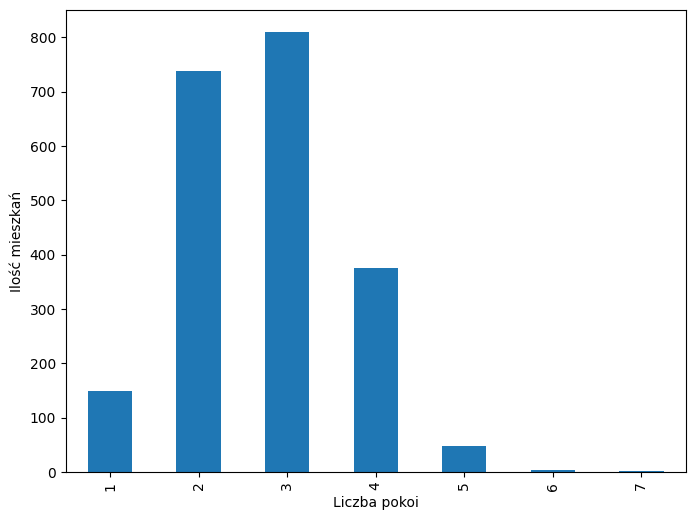

rooms_number
3    810
2    738
4    375
1    149
5     48
6      3
7      1
Name: count, dtype: int64

In [ ]:
df['rooms_number'].value_counts().sort_index().plot(kind='bar', figsize=(8,6))
plt.xlabel('Liczba pokoi')
plt.ylabel('Ilość mieszkań')
plt.show()
df["rooms_number"].value_counts()

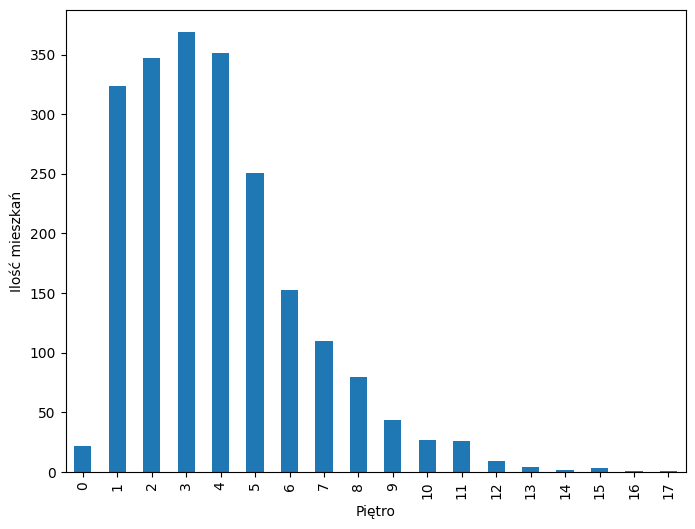

floor_number
3     369
4     351
2     347
1     324
5     251
6     153
7     110
8      80
9      44
10     27
11     26
0      22
12      9
13      4
15      3
14      2
16      1
17      1
Name: count, dtype: int64

In [ ]:
df['floor_number'].value_counts().sort_index().plot(kind='bar', figsize=(8,6))
plt.xlabel('Piętro')
plt.ylabel('Ilość mieszkań')
plt.show()
df["floor_number"].value_counts()

Text(0.5, 1.0, 'Rozkład rozmiaru mieszkań')

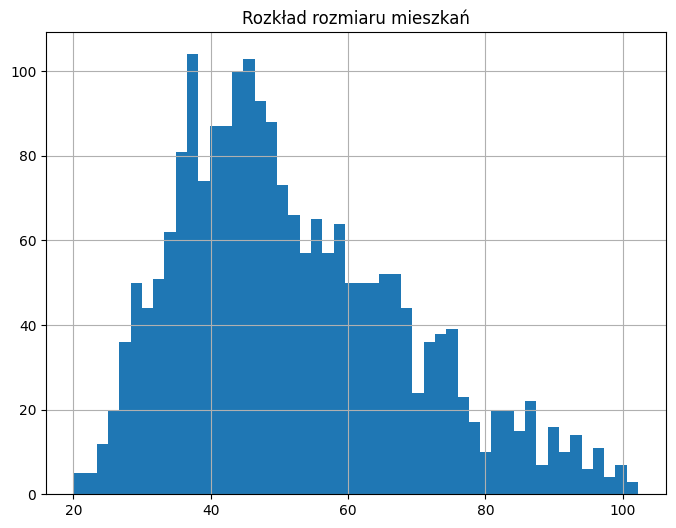

In [ ]:
plt.figure(figsize=(8,6))
df["size"].hist(bins=50)
plt.title('Rozkład rozmiaru mieszkań')

Text(0.5, 1.0, 'Rozkład ceny za m2')

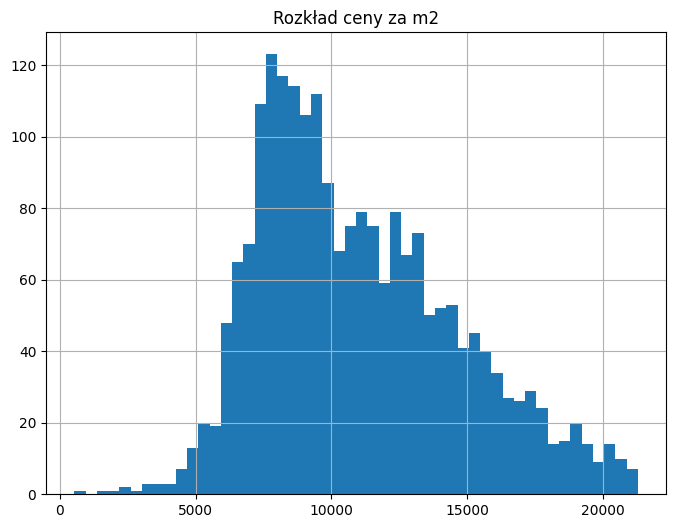

In [ ]:
plt.figure(figsize=(8,6))
df["amount_sqm"].hist(bins=50)
plt.title('Rozkład ceny za m2')

In [ ]:
gb = df.groupby('rooms_number')['size'].mean()
print(gb)
gb = df.groupby('rooms_number')['amount_sqm'].mean()
print(gb)
gb = df.groupby('floor_number')['amount_sqm'].mean()
print(gb)


rooms_number
1   31.94
2   41.47
3   55.66
4   70.13
5   82.23
6   70.83
7   67.40
Name: size, dtype: float64
rooms_number
1   12,380.67
2   11,751.64
3   10,631.50
4    9,976.21
5    9,820.38
6    9,014.75
7    4,525.22
Name: amount_sqm, dtype: float64
floor_number
0     9,001.06
1    10,619.15
2    10,771.36
3    10,975.23
4    11,127.44
5    11,205.70
6    11,381.19
7    11,369.22
8    11,176.02
9    11,120.25
10   11,663.67
11   11,385.65
12   12,761.29
13   13,574.73
14   10,321.70
15    9,456.35
16   13,242.20
17   10,795.55
Name: amount_sqm, dtype: float64


In [ ]:
#Mała liczba obserwacji w mieszkaniach 6 i 7 osobowych oraz wysokich pięter

!Mała liczba obserwacji w mieszkaniach 6 i 7 osobowych oraz wysokich pięter

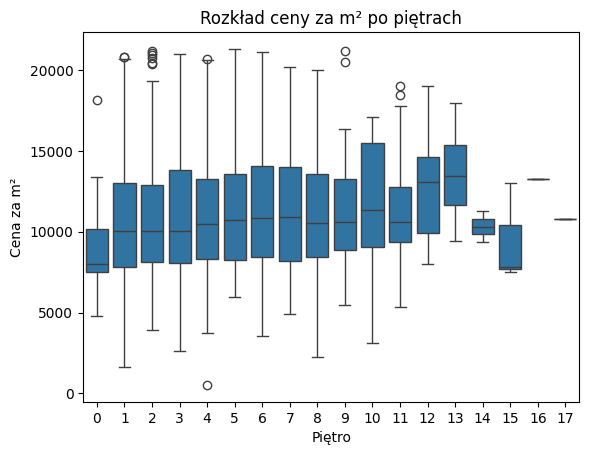

In [ ]:
sns.boxplot(x='floor_number', y='amount_sqm', data=df)
plt.xlabel('Piętro')
plt.ylabel('Cena za m²')
plt.title('Rozkład ceny za m² po piętrach')
plt.show()

Text(0.5, 1.0, 'Sprzedaż w czasie')

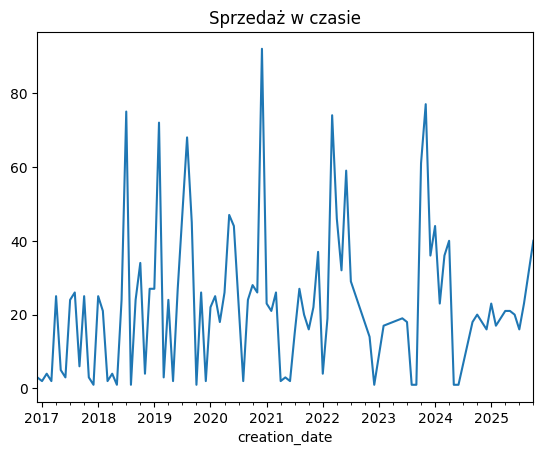

In [ ]:
df['creation_date'] = pd.to_datetime(df['creation_date'])
df.groupby(df['creation_date'].dt.to_period('M')).size().plot()
plt.title('Sprzedaż w czasie')

In [ ]:
df['month'] = df['creation_date'].dt.month
df['year'] = df['creation_date'].dt.year
monthly_counts = df.groupby(['year', 'month']).size()

# Sortowanie po wartościach (malejąco)
monthly_counts_sorted = monthly_counts.sort_values(ascending=False).head()

print(monthly_counts_sorted)

year  month
2020  12       92
2023  11       77
2018  7        75
2022  3        74
2019  2        72
dtype: int64
